/data/gravwav/koley/my_venv/lib/python3.10/site-packages/obspy/io/stationxml/core.py:91: UserWarning: The StationXML file has version 1.2, ObsPy can read versions (1.0, 1.1). Proceed with caution.
  warnings.warn("The StationXML file has version %s, ObsPy can "


Latitude: 50.756763
Longitude: 5.906114
Elevation (m): 150.0
[TERZ_BHZ] chunk 1/12: owner=[0.0,7200.0) read=[0.0,11400.0)
[TERZ_BHZ] chunk 2/12: owner=[7200.0,14400.0) read=[6600.0,18600.0)
[TERZ_BHZ] chunk 3/12: owner=[14400.0,21600.0) read=[13800.0,25800.0)
[TERZ_BHZ] chunk 4/12: owner=[21600.0,28800.0) read=[21000.0,33000.0)
[TERZ_BHZ] chunk 5/12: owner=[28800.0,36000.0) read=[28200.0,40200.0)
[TERZ_BHZ] chunk 6/12: owner=[36000.0,43200.0) read=[35400.0,47400.0)
[TERZ_BHZ] chunk 7/12: owner=[43200.0,50400.0) read=[42600.0,54600.0)
[TERZ_BHZ] chunk 8/12: owner=[50400.0,57600.0) read=[49800.0,61800.0)
[TERZ_BHZ] chunk 9/12: owner=[57600.0,64800.0) read=[57000.0,69000.0)
[TERZ_BHZ] chunk 10/12: owner=[64800.0,72000.0) read=[64200.0,76200.0)
[TERZ_BHZ] chunk 11/12: owner=[72000.0,79200.0) read=[71400.0,83400.0)
[TERZ_BHZ] chunk 12/12: owner=[79200.0,86400.0) read=[78600.0,86400.0)
[TERZ_BHZ] saved to /data/gravwav/koley/PSDHistBoreholes/PSDLengthAnalysis/TERZ_BHZ_pair_hist.pkl

Saved fi

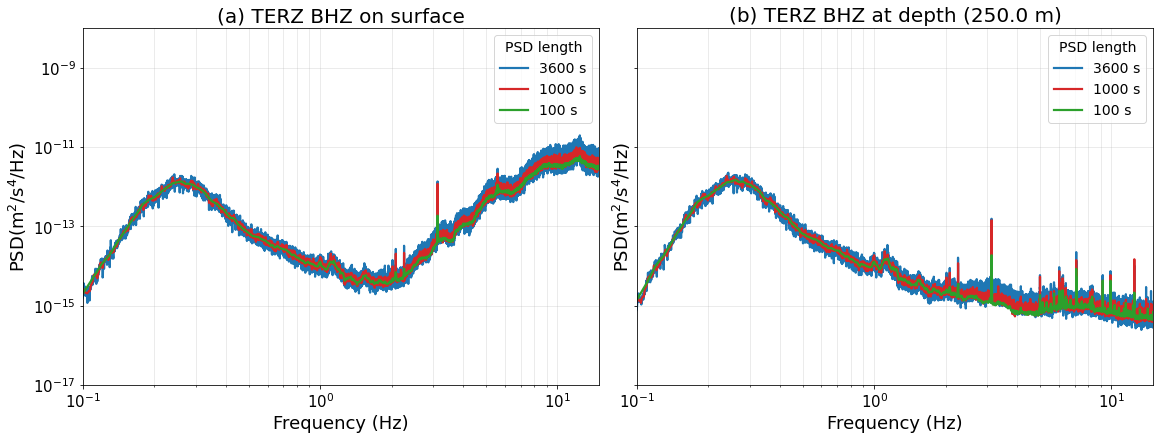

<Figure size 720x504 with 0 Axes>

<Figure size 720x504 with 0 Axes>

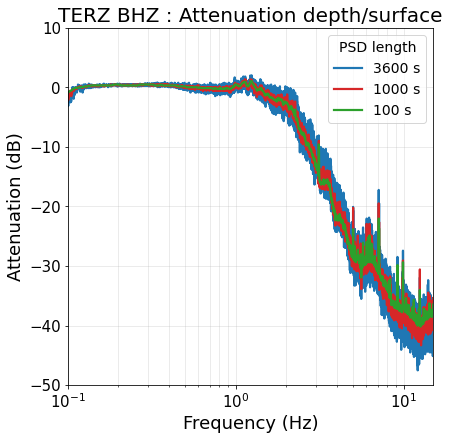

<Figure size 720x504 with 0 Axes>

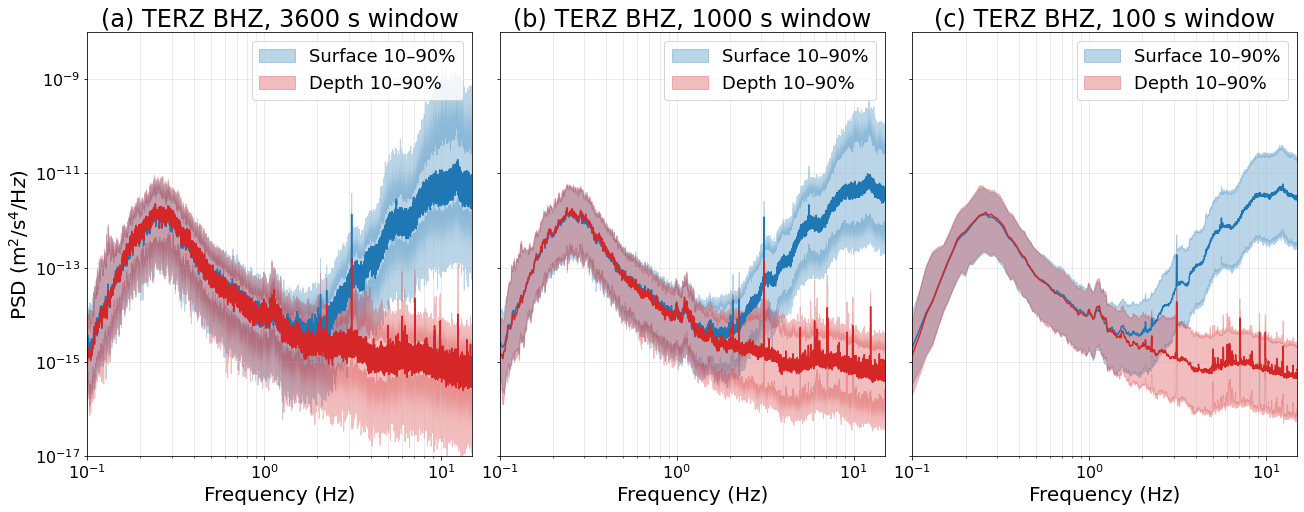

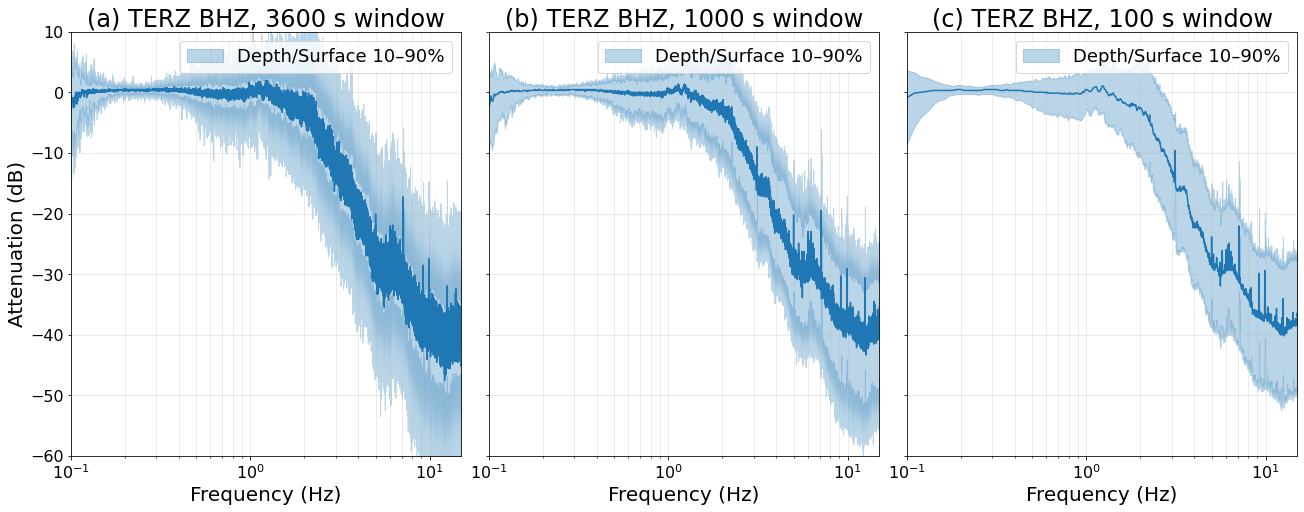

In [8]:
import os
import re
import math
import pickle
import datetime
import numpy as np
import scipy.signal as sp
import matplotlib.pyplot as plt

from obspy import read_inventory, UTCDateTime
from obspy.clients.filesystem.sds import Client
from modules import psdLenMod

# ============================================================
# User configuration
# ============================================================
rootP2 = '/dcache/etseis/et/EMR/Data'
archiveP2 = Client(rootP2)
stnName = 'TERZ'
compName = 'BHZ'
dateStVec = np.array([7])
yearVec = np.array([2026])
nDays = 1

inventory_files = {
    stnName: '/dcache/etseis/et/EMR/Stations/Stations/NL.' + stnName + '.xml',
}
inventories = {sta: read_inventory(path) for sta, path in inventory_files.items()}

# extract the station location and depth
net = inventories[stnName].select(network="NL", station=stnName, location="01", channel=compName)[0]
sta01 = net.stations[0]
cha01 = sta01.channels[0]
cha01Depth = cha01.depth
print("Latitude:", sta01.latitude)
print("Longitude:", sta01.longitude)
print("Elevation (m):", sta01.elevation)

##
preFilt_default = [0.05, 0.1, 16, 18]

psd_lengths = [3600, 1000, 100]
chunk_owner_sec = 7200
response_pad_sec = 600

# PSD histogram settings (linear PSD stored in log10 space)
logPsdMin = -24
logPsdMax = -8
nHistBins_psd = 800
hist_edges_psd = np.linspace(logPsdMin, logPsdMax, nHistBins_psd + 1)

# attenuation histogram settings in dB
attDbMin = -80
attDbMax = 40
nHistBins_att = 800
hist_edges_att = np.linspace(attDbMin, attDbMax, nHistBins_att + 1)

output_dir = '/data/gravwav/koley/PSDHistBoreholes/PSDLengthAnalysis/'
os.makedirs(output_dir, exist_ok=True)

pair_configs = [
    {
        "label": stnName + '_' + compName,
        "ch0": {
            "station": stnName,
            "network": "NL",
            "location": "00",
            "channel": compName,
            "inventory_key": stnName,
            "use_prefilt": True,
            "pre_filt": preFilt_default,
            "output_unit": "VEL",
        },
        "ch1": {
            "station": stnName,
            "network": "NL",
            "location": "01",
            "channel": compName,
            "inventory_key": stnName,
            "use_prefilt": True,
            "pre_filt": preFilt_default,
            "output_unit": "VEL",
        },
        "depth_diff_m": cha01Depth,
    },
]

# ============================================================
# Main
# ============================================================
day0 = int(dateStVec[0])
year0 = int(yearVec[0])
A = datetime.datetime(year0, 1, 1) + datetime.timedelta(days=day0 - 1)
dateUse = UTCDateTime(A.year, A.month, A.day)

saved_files = []
for pair_cfg in pair_configs:
    outfile = psdLenMod.process_one_pair(archive=archiveP2, pair_cfg=pair_cfg, inventories=inventories, preFilt_default=preFilt_default,
                                         dateUse=dateUse, nDays=nDays, psd_lengths=psd_lengths, chunk_owner_sec=chunk_owner_sec,
                                         response_pad_sec=response_pad_sec, hist_edges_psd=hist_edges_psd, hist_edges_att=hist_edges_att,
                                         output_dir=output_dir)
    if outfile is not None:
        saved_files.append(outfile)

print("\nSaved files:")
for f in saved_files:
    print(f)

for f in saved_files:
    psdLenMod.plot_pair_results(f,cha01Depth,title_prefix=stnName + ' '+ compName)
    
psdLenMod.plot_prct_bands(outfile, lengths_to_plot=(3600, 1000, 100), qty_key= 'PSD', title_prefix=stnName + ' '+ compName)
psdLenMod.plot_prct_bands(outfile, lengths_to_plot=(3600, 1000, 100), qty_key= 'Attn', title_prefix=stnName + ' '+ compName)
